# Drought severity from JRC/EDO's Soil Moisture Index

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/jrc_edo_drought_index.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/jrc_edo_drought_index.ipynb)

**crc-sdk** exposes JRC/EDO drought data through the same immutable, lazy `HazardDataset` workflow as JRC flood maps. The workflow resolves a versioned dataset, selects an AOI and complete years, caches compact annual-minimum AOI rasters, and materializes canonical H3 curves.

1. **Snapshot** -- a single dekad's raw Soil Moisture Index (SMI), sampled straight to H3 cells (`NetCDFRaster.scan_h3`), just to see the raw grid before any hazard modeling.
2. **Hazard** -- canonicalize source-pixel drought curves into overlapping H3 cells from complete years of dekadal SMI. Each annual minimum becomes one curve knot with an empirical Gringorten return period.
3. **Escalation** -- compare exposed-cell count and worst-case severity across return periods, from a common (1-in-2-year) to a rare (1-in-25-year) drought.
4. **Visualize** -- a severity map at a chosen design return period, and a return-period comparison.

Nothing is bundled with this notebook. The source cache stores checksummed annual-minimum AOI rasters rather than full yearly files; after `prefetch()`, the same plan can run in offline mode.

**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-assess-asset-portfolio-risk/SKILL.md) · [Python pipeline](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/jrc_drought_pipeline.py) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)


## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages and downloads any small repository files used by the analysis.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry,netcdf]==0.7.1', 'crc-framework==0.2.5', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from shapely.geometry import mapping

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.connectors.duckdb.netcdf import NetCDFRaster
from crc_sdk.geometry import cell_polygon
from crc_sdk.providers.jrc_edo import SMI, EDOProvider
from crc_sdk.workflows import (
    EDODroughtPolicy,
    HazardDataset,
    curve_quantiles_at,
    return_periods_to_probabilities,
    warn_if_extrapolated,
)

# Use the native interactive renderer; maintainers can opt into saved PNG previews.
STATIC_PREVIEW = os.environ.get("CRC_NOTEBOOK_STATIC_PREVIEW") == "1"
pio.renderers.default = (
    "colab" if IN_COLAB else "plotly_mimetype+png" if STATIC_PREVIEW else "plotly_mimetype"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# A patch of western/central Germany, well inside EDO's European coverage.
# SMI (crc_sdk.providers.jrc_edo.SMI) already knows this dataset's base URL,
# per-year filename convention, and variable name, so nothing NetCDF- or
# EDO-format-specific lives here.
BOUNDS = (9.5, 50.5, 10.5, 51.5)
YEARS = tuple(range(1995, 2026))
RETURN_PERIODS = [2, 5, 10, 25]
DESIGN_RETURN_PERIOD = 10

## 1. Snapshot: one dekad's raw SMI, straight to H3

Before fitting anything, `NetCDFRaster` -- crc-sdk's generic NetCDF/HDF5 connector -- reads a single dekad straight off JRC/Copernicus's HTTP server and samples it to H3 cells in one pass, the same lazy `scan_h3` shape `GeoTiffRaster` already has for GeoTIFF/COG. There's no GDAL-VSI-equivalent single blessed way to stream a remote NetCDF file, but the server advertises `Accept-Ranges: bytes`, so `h5netcdf` + `fsspec` can seek straight to the bytes a read needs instead of downloading the whole (~300+ MB) yearly file.

SMI is nominally bounded in [0, 1] (0 = wilting point, 1 = field capacity), though the underlying model can push slightly outside that range under extreme conditions -- worth keeping in mind for the low end of the color scale below.

In [3]:
SNAPSHOT_YEAR = 2023

provider = EDOProvider(SMI, work_dir=DATA_DIR)
with NetCDFRaster.open(provider.year_url(SNAPSHOT_YEAR), variable=SMI.variable) as raster:
    snapshot = raster.scan_h3(bounds=BOUNDS, h3_resolution=6).relation().df()

print(f"{len(snapshot)} H3 cells sampled from the last dekad's SMI grid, year {SNAPSHOT_YEAR}")
snapshot.head()

276 H3 cells sampled from the last dekad's SMI grid, year 2023


,cell,value
0,604029032027127807,0.928007
1,604029032295563263,0.901552
2,604029039409102847,0.901233
3,604029039543320575,0.875285
4,604029039677538303,0.928997


## 2. Hazard: annual block-minima curves indexed by H3

JRC's flood maps ship one raster *per return period* already. EDO's SMI is instead a continuous dekadal time series, so `HazardDataset.smi(...)` reduces each selected complete year to its minimum SMI, assigns empirical return periods with the Gringorten plotting position, and fits the same canonical curve model with a persisted lower-tail convention. The curated policy requires at least 20 complete years; this example uses all 31 complete years from 1995 through 2025.

A fitted curve can be evaluated anywhere, but that does not make every result equally supported by observations. With 31 annual minima, the nominal fitted support extends to about a 1-in-56-year event, so RP25 is interpolation. A six-year record would support only about RP11, making RP25 extrapolation. The SDK persists this support and emits `ReturnPeriodExtrapolationWarning` whenever evaluation leaves it. Flood evaluation follows the same rule: for source rasters RP10 through RP500, RP250 is interpolation and RP1000 is extrapolation.

In [4]:
CURVES_PATH = DATA_DIR / "jrc_edo_drought_curves.parquet"

plan = (
    HazardDataset.smi(version="latest")
    .for_area(BOUNDS)
    .years(YEARS)
    .cache(DATA_DIR / "edo-smi-source-cache", mode="reuse")
    .canonicalize(policy=EDODroughtPolicy.curated(h3_resolution=6))
)
print(plan.explain())
# Rebuild with the current policy; reuse validated source crops when available.
drought = plan.materialize(CURVES_PATH)

# Round-trip through the canonical contract: read back the file just
# written, then reconstruct a severity at each requested return period --
# the same read path pipelines/jrc_drought_pipeline.py uses.
metadata = drought.metadata()
warn_if_extrapolated(RETURN_PERIODS, metadata.return_period_support)
curves = read_hazard_dataset(drought.provider.source)
print("Canonical curve treatments:", curves["curve_kind"].value_counts().to_pylist())
probabilities = return_periods_to_probabilities(
    RETURN_PERIODS, tail=metadata.return_period_tail
)
severity = pd.concat(
    [
        pd.DataFrame(
            {
                "cell": curves["cell_index"].to_pylist(),
                "smi": curve_quantiles_at(curves, probability),
                "return_period": rp,
            }
        )
        for rp, probability in zip(RETURN_PERIODS, probabilities)
    ],
    ignore_index=True,
)
# One H3 cell can have more than one contributing source pixel -- EDO's own
# conservative H3 overlap coverage already produces this within a single
# year's grid -- so cells are reduced to their worst-case (minimum SMI)
# severity per return period.
severity = severity.groupby(["cell", "return_period"], as_index=False).min()
print(
    f"{len(severity):,} cell-return-period rows across "
    f"{severity['cell'].nunique():,} distinct H3 cells"
)

Dataset: jrc-edo-soil-moisture-index
Requested version: latest
Resolved version: 3.0.1
Area: 9.5,50.5,10.5,51.5
Years: 1995-2025
Cache: reuse (data/edo-smi-source-cache)
Tail: lower
Network access and fitting occur only at prefetch/materialize/write.


Canonical curve treatments: [{'values': 'fitted', 'counts': 6360}]


1,144 cell-return-period rows across 286 distinct H3 cells


## 3. Escalation: exposed cells and severity by return period

Compare valid cell counts and hazard values across return periods. Count flood
exposure only where depth is positive; count drought exposure against an explicit
SMI threshold. The number of evaluated rows alone does not measure an expanding
hazard footprint. Null values indicate unavailable evidence, not zero hazard.


In [5]:
summary = (
    severity.groupby("return_period")
    .agg(
        evaluated_cells=("smi", "count"),
        mean_smi=("smi", "mean"),
        worst_smi=("smi", "min"),
    )
    .reset_index()
)
summary

,return_period,evaluated_cells,mean_smi,worst_smi
0,2,286,0.573742,0.350695
1,5,286,0.456711,0.214269
2,10,286,0.406805,0.156267
3,25,286,0.360057,0.102014


## 4. Visualize

A severity map at the design return period, and an escalation chart across all four requested return periods. SMI uses one sequential scale (YlOrBr, reversed so drier/more severe reads darker) throughout -- a magnitude, never a diverging quantity in this context -- and a dark basemap keeps the map legible.

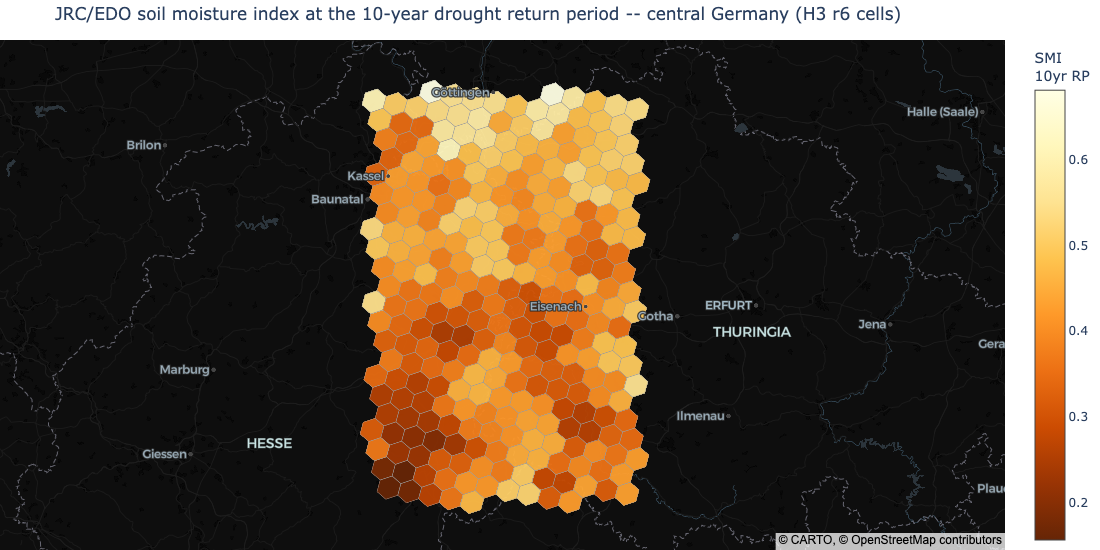

In [6]:
MAP_STYLE = "carto-darkmatter"  # dark basemap: low-contrast severity values stay legible
severity_design_rp = severity[severity["return_period"] == DESIGN_RETURN_PERIOD]

hex_geojson = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": str(cell), "geometry": mapping(cell_polygon(cell))}
        for cell in severity_design_rp["cell"]
    ],
}

fig_hex = go.Figure(
    go.Choroplethmap(
        geojson=hex_geojson,
        locations=severity_design_rp["cell"].astype(str),
        z=severity_design_rp["smi"],
        colorscale="YlOrBr",
        reversescale=True,
        marker_line_width=0.3,
        marker_line_color="#999999",
        marker_opacity=0.95,
        colorbar_title=f"SMI<br>{DESIGN_RETURN_PERIOD}yr RP",
    )
)
fig_hex.update_layout(
    map_style=MAP_STYLE,
    map_zoom=7.4,
    map_center={"lat": (BOUNDS[1] + BOUNDS[3]) / 2, "lon": (BOUNDS[0] + BOUNDS[2]) / 2},
    margin=dict(l=0, r=0, t=40, b=0),
    title=(
        f"JRC/EDO soil moisture index at the {DESIGN_RETURN_PERIOD}-year drought "
        "return period -- central Germany (H3 r6 cells)"
    ),
)
fig_hex.show()

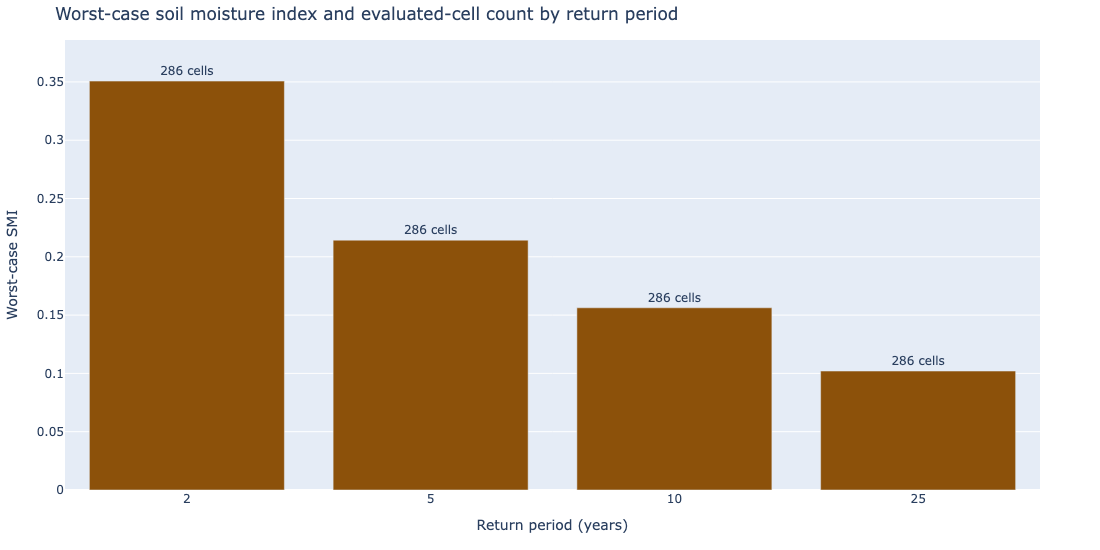

In [7]:
ranked = summary.sort_values("return_period")
fig_escalation = go.Figure(
    go.Bar(
        x=[str(rp) for rp in ranked["return_period"]],
        y=ranked["worst_smi"],
        marker_color="#8C510A",
        text=ranked["evaluated_cells"],
        texttemplate="%{text:,} cells",
        textposition="outside",
        customdata=ranked[["mean_smi"]],
        hovertemplate=(
            "RP %{x}yr<br>Worst-case SMI: %{y:.3f}"
            "<br>Mean SMI: %{customdata[0]:.3f}<extra></extra>"
        ),
    )
)
fig_escalation.update_layout(
    title="Worst-case soil moisture index and evaluated-cell count by return period",
    xaxis_title="Return period (years)",
    yaxis_title="Worst-case SMI",
    margin=dict(l=60, r=60, t=40, b=60),
)
fig_escalation.show()

## Scaling this up

[`pipelines/jrc_drought_pipeline.py`](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/jrc_drought_pipeline.py) is this notebook's headless twin. Change the bounds or complete-year range, or use `.years("all_complete")` to let the provider discover every fully published year. `reuse` validates checksummed annual-minimum AOI files, `refresh` replaces them, and a prefetched plan can switch to `offline`. The curated policy enforces a defensible record length, while the persisted empirical support makes interpolation and extrapolation explicit at evaluation time.